In [292]:
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt

In [293]:
# Basic parameters for the experiment
SHARE_NUMBER = N = 10
MINIMUM_SHARE = K = 3
BITLENGTH = M = 8
ALPHA = ...
R = (..., ...) # sould be symmetrical in case of experiment, but we also have asymmetrical cases (ref paper).

In [294]:
# Preparing types for data

# a 1D array of bits with shape size of M
Share = npt.NDArray[np.bool_] 
# a 2D array of bits with shape size of N x M
C_Matrix = npt.NDArray[np.bool_]

In [302]:
def display(share: Share | C_Matrix, fmt: tuple[int, int] = (1, -1), Label: str = "", grid=False) -> None:
    """Display a single share as an image."""
    fig, ax = plt.subplots()
    # check if the share can be reshaped to the specified format
    if share.size != np.prod(fmt) and fmt != (1, -1):
        raise ValueError(f"Cannot reshape share of size {share.size} to format {fmt}.")
    
    # quick way to reshape the share if it's 1D, otherwise keep it as is
    match share.ndim:
        case 1: 
            share_reshaped = share.reshape(fmt)  
        case 2: 
            share_reshaped = share
        case _: 
            raise ValueError(f"Unsupported share dimensions: {share.ndim})")
    assert share_reshaped.ndim == 2, "Share must be 2D after reshaping."

    h, w = share_reshaped.shape
    ax.imshow(
        share_reshaped,
        cmap="gray_r",
        vmin=0,
        vmax=1
    )

    # Explicit separators on top of the image to avoid backend/style grid quirks
    if grid:
        for x in range(w + 1):
            ax.axvline(x - 0.5, color="lightgray", linewidth=1)
        for y in range(h + 1):
            ax.axhline(y - 0.5, color="lightgray", linewidth=1)

    ax.set_xlim(-0.5, w - 0.5)
    ax.set_ylim(h - 0.5, -0.5)
    ax.set_title(Label)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
    plt.show()

In [296]:
def shuffle(matrix: C_Matrix)-> None:
    """Shuffle the column of a matrix."""
    np.random.shuffle(matrix.T)
    matrix.T


def random_sampling_shares(C_0: C_Matrix, C_1: C_Matrix, secret_pixel: bool|None=None) ->tuple[bool, list[Share]]:
    """
    TODO validate that this process is as described in the paper.
    Emulate a Random share creation based on the two matrix C_0 and C_1.
    based on a secrete pixel 
    
    output 
    - list share: the generated share as a 1D array of bits (size M) 
    """
    
    if C_0.shape != C_1.shape:
        raise ValueError(f"C_0 and C_1 must have the same shape, got {C_0.shape} and {C_1.shape}.")
    N, _ = C_0.shape
    
    secret_pixel_value = secret_pixel if secret_pixel is not None else np.random.choice([False, True])
    C = C_1 if secret_pixel_value else C_0
    
    shares = []
    for i in range(N):
        share = C[i]
        shares.append(share)
    return secret_pixel_value, shares
    

Test matrix of shares:
[False False  True  True  True False False  True]


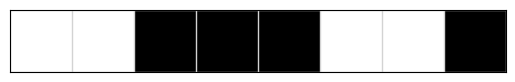

Test matrix 2 of shares:
[ True  True  True  True False False False  True]


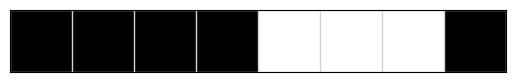

Result of share addition:
[ True  True  True  True  True False False  True]


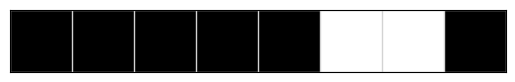

In [297]:
def share_add(a_share: Share, b_share: Share) -> Share:
    assert a_share.shape == b_share.shape, "Shares must have the same shape for addition."
    return np.logical_or(a_share, b_share)

def matrix_share_add(matrix_share: C_Matrix) -> Share:
    assert matrix_share.ndim == 2, "Input must be a 2D matrix of shares."
    return np.logical_or.reduce(matrix_share, axis=0)

SHARE_SIZE = (BITLENGTH,)
test_matrix = np.random.randint(0, 2, size=SHARE_SIZE).astype(bool)
test_m2 = np.random.randint(0, 2, size=SHARE_SIZE).astype(bool)
print("Test matrix of shares:")
print(test_matrix)
display(test_matrix)
print("Test matrix 2 of shares:")
print(test_m2)
display(test_m2)
result = share_add(test_matrix, test_m2)
print("Result of share addition:")
print(result)
display(result)

# First impl, 3 out of 3 shares
- size of shares: 4 bits
- number of shares: 3
- C=(3, 4)

Thus:

- $C_{0}$ is a column of 0s concatenated with negated identity matrix.
- $C_{1}$ is the negated version of C_0.

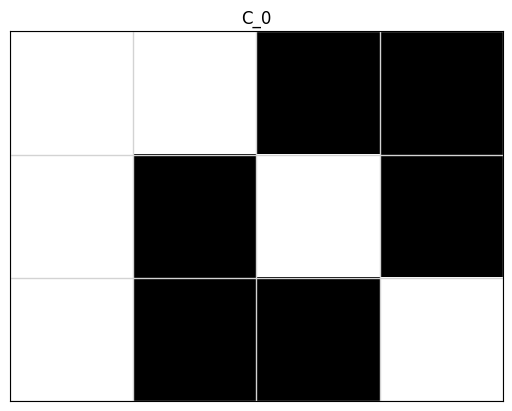

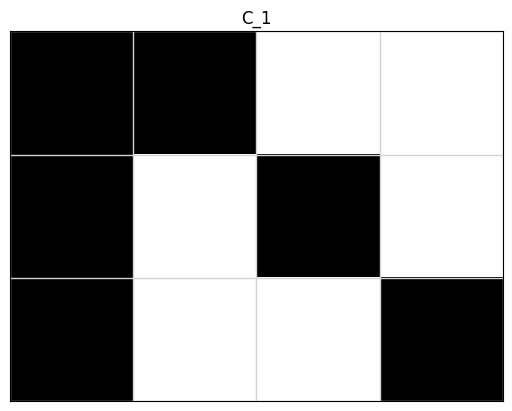

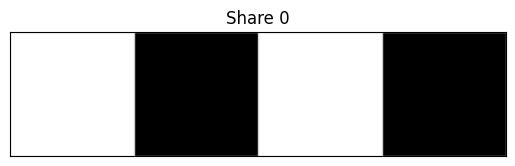

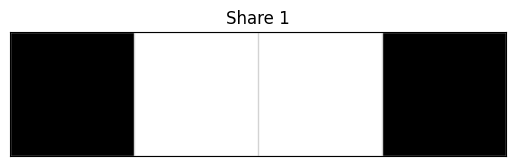

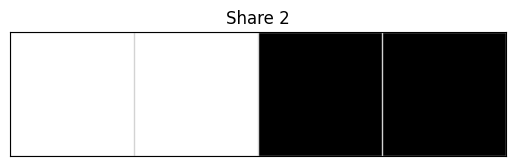

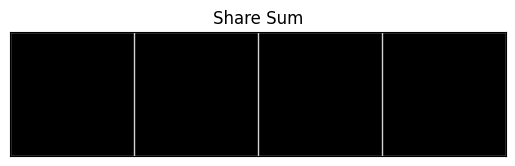

Average of share sum: 1.0
The secret should be True. (black, 1) 
Secret pixel value: True


In [298]:
SHARE_SIZE = 4
N = 3
C_1 = np.hstack((np.ones((N, 1), dtype=bool), np.eye(N, dtype=bool)))
C_0 = ~C_1

display(C_0, Label="C_0")
display(C_1, Label="C_1")

shuffle(C_0)
shuffle(C_1)

secret, shares = random_sampling_shares(C_0, C_1)
for i, share in enumerate(shares):
    display(share, Label=f"Share {i}")
share_sum = matrix_share_add(np.array(shares))
display(share_sum, Label="Share Sum")
avg = np.average(share_sum)
print(f"Average of share sum: {avg}")
if avg == 0.75:
    print("The secret should be False. (white, 0) ")
elif avg == 1.0:
    print("The secret should be True. (black, 1) ")
print (f"Secret pixel value: {secret}")
    



# General K out of K scheme
- size of shares: $2^k$ bit
- number of shares: $2^{k-1}$ subpixels

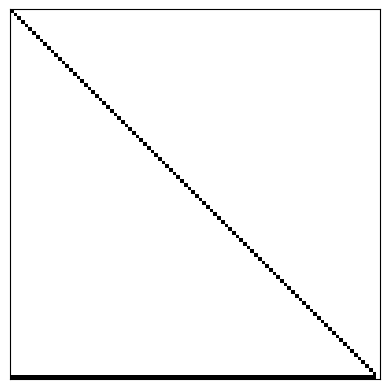

In [304]:
K = 100
def generate_C_matrices(K: int) -> tuple[C_Matrix, C_Matrix]:
    C_0 = np.eye(K, dtype=bool)
    C_0[-1,:] = ~C_0[-1,:]
    C_1 = ... # TODO generate C_1 based on the paper reed-Muller first order code.
    return C_0, C_1

C_0, C_1 = generate_C_matrices(K)

display(C_0)